In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False # -(마이너스) 기호 깨짐 방지

df = pd.read_csv('data/california.csv')

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [97]:
df.shape

(17000, 9)

In [98]:
# 결측지를 랜덤하게 생성하기

df_missing = df.copy() # 데이터프레임의 복사본 만들기
miss_count = 20 #만들 격측지 개수

# 랜덤결과를 동일하게 만들기위한 랜덤 생성자 만들기
rng = np.random.default_rng(42)

rows = rng.integers(0, df.shape[0], size=miss_count)
cols = rng.integers(0, df.shape[1], size=miss_count)

print(rows)
print(cols)

[ 1517 13157 11127  7460  7361 14596  1461 11855  3424  1601  8950 16585
 12507 12939 12197 13363  8724  2177 14275  7656]
[4 3 1 8 7 5 3 7 4 3 4 2 0 4 7 0 7 7 2 5]


In [99]:
# 랜덤한 셀(위치)에 NaN값을 대입
for i in range(miss_count):
    df_missing.iloc[rows[i],cols[i]] = np.nan



In [100]:
df_missing.isna()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
16995,False,False,False,False,False,False,False,False,False
16996,False,False,False,False,False,False,False,False,False
16997,False,False,False,False,False,False,False,False,False
16998,False,False,False,False,False,False,False,False,False


In [101]:
# 각 컬럼들의 결측지 개수를 확인하기
df_missing.isna().sum()

longitude             2
latitude              1
housing_median_age    2
total_rooms           3
total_bedrooms        4
population            2
households            0
median_income         5
median_house_value    1
dtype: int64

In [102]:
# 전체 데이터의 결측지 개수
print(df_missing.isna().sum().sum())

20


In [103]:
s = pd.Series([False, False, True, False])
print(s.values.any())

s = pd.Series([False, False, False])
print(s.values.any())

True
False


In [104]:
# 전체 데이터에는 결측지가 존재한다는것을 확인
df_missing.isnull().values.any()

True

In [105]:
# 결측지가 포함된 행만 출력하기
df_missing_res = df_missing[df_missing.isna().any(axis=1)]
df_missing_res


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
1461,-117.19,32.80,16.0,NaN,794.0,1235.0,684.0,3.1304,166300.0
1517,-117.21,33.82,2.0,4198.0,NaN,1943.0,673.0,3.9052,122100.0
1601,-117.23,34.11,33.0,NaN,500.0,1425.0,472.0,2.0133,78300.0
2177,-117.37,33.19,23.0,4104.0,1274.0,4729.0,1187.0,NaN,173800.0
3424,-117.89,33.99,22.0,3272.0,NaN,1784.0,591.0,4.0324,211300.0
7361,-118.35,34.16,42.0,2267.0,478.0,1083.0,458.0,NaN,250000.0
7460,-118.35,33.80,19.0,6224.0,1105.0,3152.0,1076.0,5.9541,NaN
7656,-118.37,33.92,44.0,938.0,181.0,NaN,171.0,4.4722,218300.0
8724,-118.58,34.20,21.0,2979.0,744.0,1824.0,692.0,NaN,223700.0
8950,-118.89,34.33,23.0,366.0,NaN,265.0,66.0,3.1250,375000.0


In [106]:
# 결측지들을 처리하는 방법
# 1. 결측치 버리기

df_miss_res = df_missing.dropna()
df_missing_res.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 1461 to 16585
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           18 non-null     float64
 1   latitude            19 non-null     float64
 2   housing_median_age  18 non-null     float64
 3   total_rooms         17 non-null     float64
 4   total_bedrooms      16 non-null     float64
 5   population          18 non-null     float64
 6   households          20 non-null     float64
 7   median_income       15 non-null     float64
 8   median_house_value  19 non-null     float64
dtypes: float64(9)
memory usage: 1.6 KB


In [107]:
df_missing_res = df_missing.fillna(0)
df_missing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16998 non-null  float64
 1   latitude            16999 non-null  float64
 2   housing_median_age  16998 non-null  float64
 3   total_rooms         16997 non-null  float64
 4   total_bedrooms      16996 non-null  float64
 5   population          16998 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       16995 non-null  float64
 8   median_house_value  16999 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [108]:
# 모든 결측지들의 값을 평균값으로 채우기
df_missing_res = df_missing.fillna(df_missing.mean())
df_missing_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [109]:
# 수치형 컬럼들ㅇ만 별도로 추출하여 각 컬럼들의 평규능로 그 컬럼에 있는 결측지를 채움
df_missing_res = df_missing.copy()
df_numbers = df_missing_res.select_dtypes(include=['number']) # 수치할 컬럼들로만 구성된 dataFrame 만들기
cols = df_numbers.columns # 위 DataFrame의 컬럼들만 리스트로 구성하기
for col in cols : 
   df_missing_res[col] = df_missing_res[col].fillna(df_missing_res[col].mean()) 
   
   # median(): 중앙값
   # mode()[0] : 최빈값


df_missing_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [110]:
df_missing_res = df_missing.copy()

# 앞뒤값으로 채우기
df_missing_res = df_missing.ffill() # 앞 행의 값으로 채움
df_missing_res = df_missing.bfill() # 뒤 행의 값으로 채움

df_missing_res

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


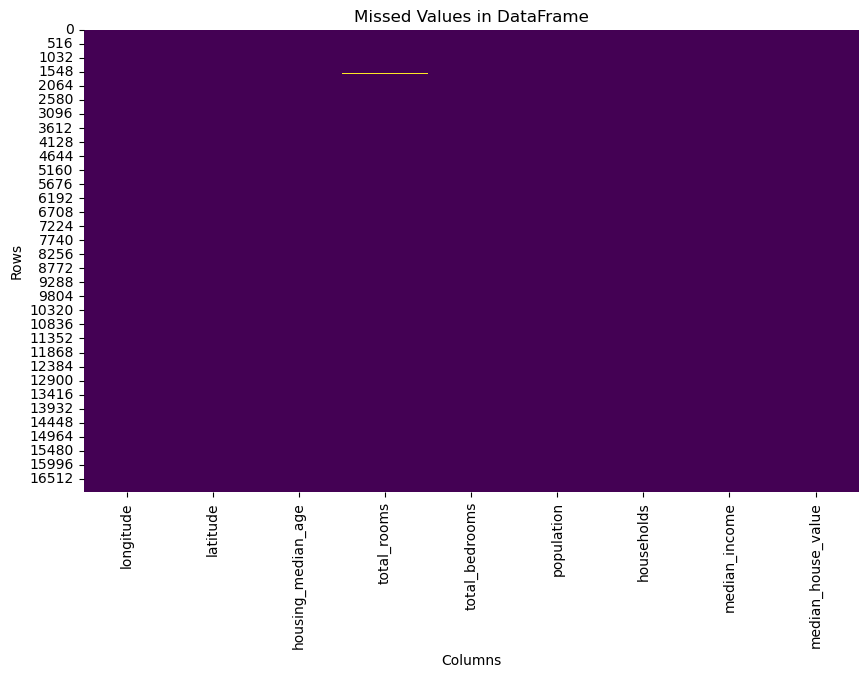

In [111]:
# 결측치를 한눈에 그래프로 보여주기
# 일반적으로 히트맵으로 보여줌

plt.figure(figsize=(10,6))
sns.heatmap(df_missing.isna(), cbar=False, cmap='viridis')
plt.title('Missed Values in DataFrame')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()